# AI Powered Payroll anomaly detection

This week I will focus on following things :-
* Detection of
  1. salary outliers
  2. abnormal deductions
  3. overtime spikes
* Calculating evaluation metrics like confusion matrix, classification report, false predictions.
* Predicting next month payroll
* Generating alerts in real time

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [12]:
payroll_data = pd.read_csv("../data/refined_data.csv")

In [13]:
payroll_data

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,salary_dev_pct,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,-0.044586,0.004920,1,0.888704,-2.020726e+00,1,1,3,1,0
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,-0.036697,-0.065462,0,-0.034851,-1.154701e+00,0,1,1,0,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,-0.024390,0.000000,2,0.801576,-8.660254e-01,0,0,2,1,0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,0.050955,-0.061674,0,-0.540192,2.309401e+00,1,1,2,1,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,-0.032258,0.023102,2,1.045534,-8.660254e-01,0,1,3,1,0
5,1006,Meera,Marketing,Marketing Exec,32000,2023-06-30,22,21,3,33500,...,-0.030303,-0.045967,1,0.261383,-8.660254e-01,0,0,1,0,0
6,1007,Vikram,IT,Senior Developer,80000,2023-07-31,22,22,10,85000,...,0.012658,-0.070806,1,-1.463747,8.660254e-01,0,1,2,1,0
7,1008,Ananya,HR,HR Manager,60000,2023-08-31,22,20,1,60500,...,0.000000,-0.041194,1,-0.052277,6.694987e-16,0,0,1,0,0
8,1009,Rahul,Finance,Finance Manager,70000,2023-09-30,22,21,2,71000,...,0.000000,-0.080464,1,-1.254640,6.694987e-16,0,0,1,0,0
9,1010,Pooja,Sales,Sales Manager,65000,2023-10-31,22,19,6,68000,...,0.000000,0.052205,1,1.951663,6.694987e-16,0,1,2,1,1


In [14]:
import seaborn as sns

In [15]:
payroll_data['total_deductions'] = payroll_data['tax_deduction'] + payroll_data['pf_deduction']
payroll_data

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly,total_deductions
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,0.004920,1,0.888704,-2.020726e+00,1,1,3,1,0,7500.0
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,-0.065462,0,-0.034851,-1.154701e+00,0,1,1,0,0,5250.0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,0.000000,2,0.801576,-8.660254e-01,0,0,2,1,0,6000.0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,-0.061674,0,-0.540192,2.309401e+00,1,1,2,1,1,8250.0
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,0.023102,2,1.045534,-8.660254e-01,0,1,3,1,0,4500.0
5,1006,Meera,Marketing,Marketing Exec,32000,2023-06-30,22,21,3,33500,...,-0.045967,1,0.261383,-8.660254e-01,0,0,1,0,0,4800.0
6,1007,Vikram,IT,Senior Developer,80000,2023-07-31,22,22,10,85000,...,-0.070806,1,-1.463747,8.660254e-01,0,1,2,1,0,12000.0
7,1008,Ananya,HR,HR Manager,60000,2023-08-31,22,20,1,60500,...,-0.041194,1,-0.052277,6.694987e-16,0,0,1,0,0,9000.0
8,1009,Rahul,Finance,Finance Manager,70000,2023-09-30,22,21,2,71000,...,-0.080464,1,-1.254640,6.694987e-16,0,0,1,0,0,10500.0
9,1010,Pooja,Sales,Sales Manager,65000,2023-10-31,22,19,6,68000,...,0.052205,1,1.951663,6.694987e-16,0,1,2,1,1,9750.0


'employee_id', 'employee_name', 'department', 'designation',
'base_salary', 'joining_date', 'working_days', 'present_days',
'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
'**updated_net_salary**', '**average_salary**', '**salary_deviation**',
'**overtime_pay_per_hour**', 'LOP_days', 'paid_leaves', 'pay_per_day',
'earned_base', '**expected_gross_salary**', '**expected_net**', '**salary_diff**',
'department_encoded', 'designation_encoded', 'anomaly_score',
'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
'**salary_dev_pct**', '**net_diff_pct**', 'rule_violation_score',
'**z_salary_diff**', '**z_salary_dev**', 'stat_anomaly', 'model_anomaly_flag',
'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly', **total_deductions**

In [16]:
plt.style.use("ggplot")

<Axes: xlabel='net_diff_pct', ylabel='Count'>

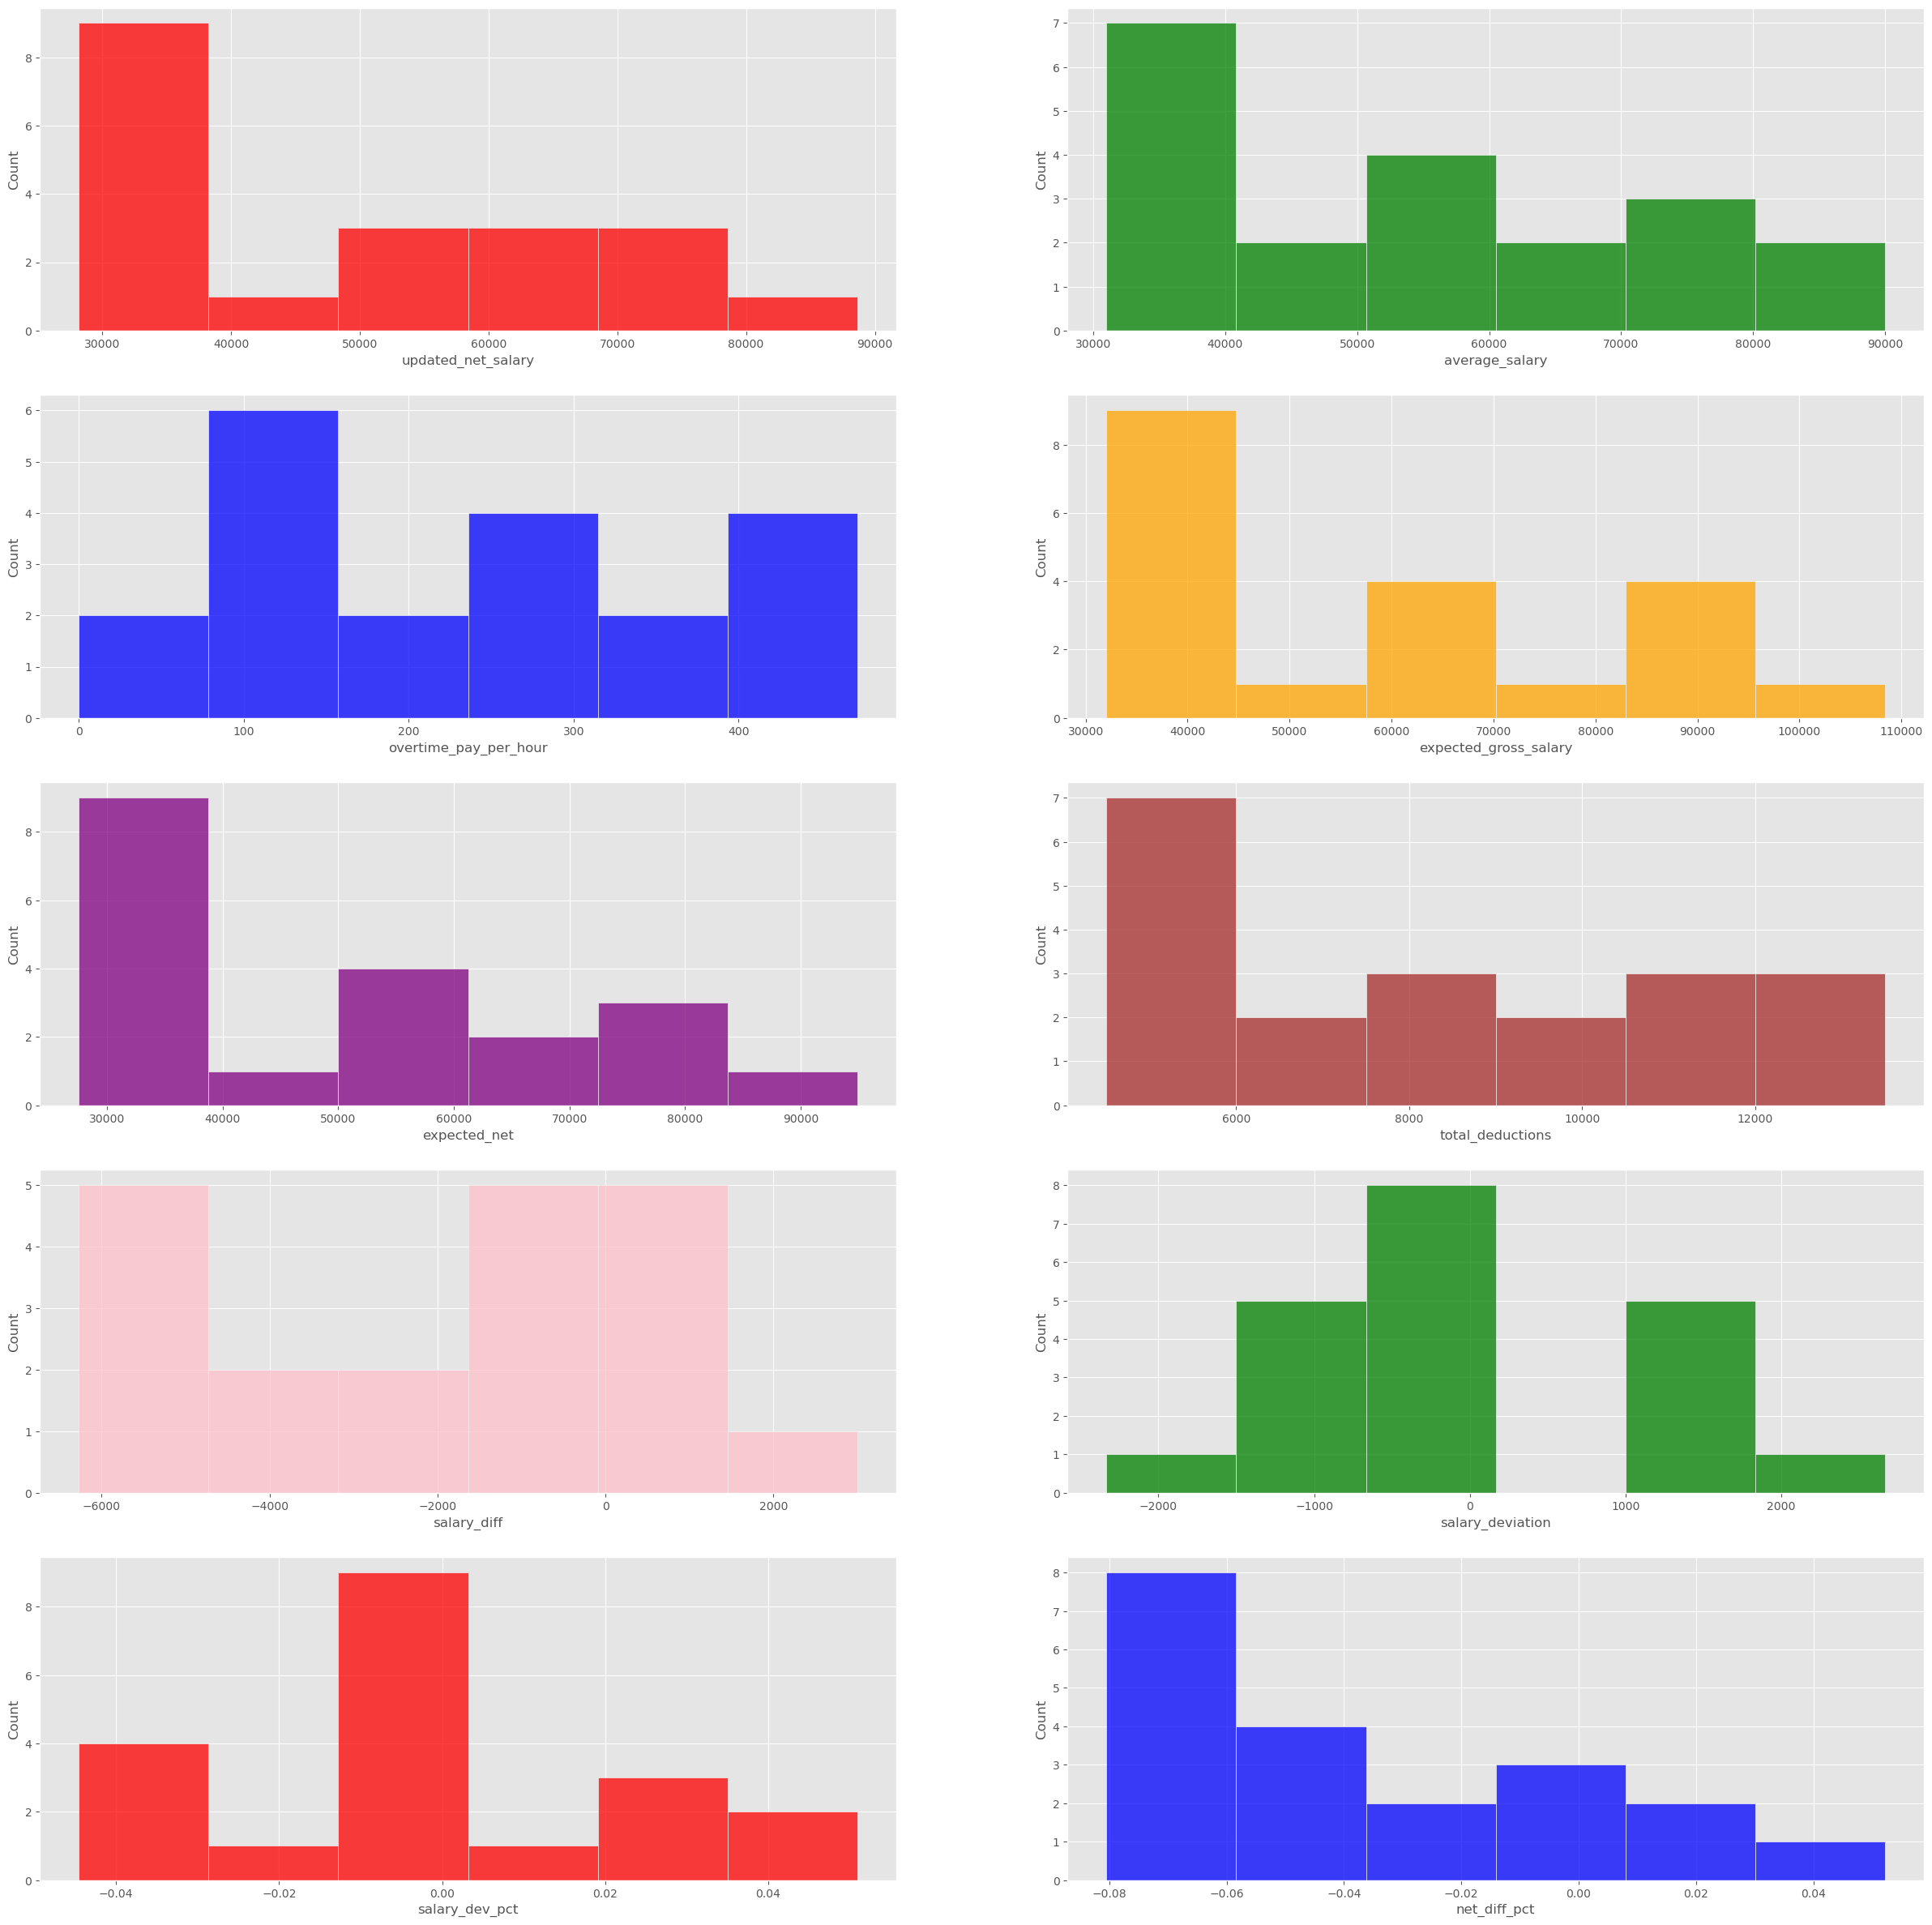

In [17]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10)) = plt.subplots(5, 2, figsize=(30, 30))

sns.histplot(payroll_data['updated_net_salary'], ax=ax1, color='red')
sns.histplot(payroll_data['average_salary'], ax=ax2, color='green')
sns.histplot(payroll_data['overtime_pay_per_hour'], ax=ax3, color='blue')
sns.histplot(payroll_data['expected_gross_salary'], ax=ax4, color='orange')
sns.histplot(payroll_data['expected_net'], ax=ax5, color='purple')
sns.histplot(payroll_data['total_deductions'], ax=ax6, color='brown')
sns.histplot(payroll_data['salary_diff'], ax=ax7, color='pink')
sns.histplot(payroll_data['salary_deviation'], ax=ax8, color='green')
sns.histplot(payroll_data['salary_dev_pct'], ax=ax9, color='red')
sns.histplot(payroll_data['net_diff_pct'], ax=ax10, color='blue')

In [18]:
fig.savefig("../plots/distributions.png", bbox_inches='tight')

**I cant use general Zscore for the detection of outliers in salary, overtime and deductions as the data is not normally distributed. Instead I will use following approaches to detect the same.**
1. Isolation forest
2. Robust Zscore
3. Hybrid approach - Risk scoring on the basis of isolation and zscore method 

## Detection using Isolation Forest

In [19]:
payroll_data['employee_id'].duplicated().any()

np.False_

In [20]:
payroll_data['employee_name'].duplicated().any()

np.False_

**Above shows that there are no duplicate employees**

In [21]:
payroll_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly,total_deductions
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,0.004920,1,0.888704,-2.020726,1,1,3,1,0,7500.0
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,-0.065462,0,-0.034851,-1.154701,0,1,1,0,0,5250.0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,0.000000,2,0.801576,-0.866025,0,0,2,1,0,6000.0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,-0.061674,0,-0.540192,2.309401,1,1,2,1,1,8250.0
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,0.023102,2,1.045534,-0.866025,0,1,3,1,0,4500.0


In [22]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions'],
      dtype='object')

In [23]:
deduction_features = [
    'tax_deduction',
    'pf_deduction',
    'total_deductions',
    'designation_encoded',
    'department_encoded'
]

X_deductions = payroll_data[deduction_features]

In [24]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_deductions)
payroll_data['deduction_anomaly_score'] = model.decision_function(X_deductions)
payroll_data['deduction_anomaly_flag'] = model.predict(X_deductions)

In [25]:
anomalies = payroll_data[payroll_data['deduction_anomaly_flag']==-1]
anomalies

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly,total_deductions,deduction_anomaly_score,deduction_anomaly_flag
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,-1.603152,6.694987e-16,0,0,1,0,0,13500.0,-0.016008,-1


In [26]:
payroll_data['deduction_anomaly_flag'].value_counts()

deduction_anomaly_flag
 1    19
-1     1
Name: count, dtype: int64

**There is only one abnormal deductions in dataset**

In [27]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions', 'deduction_anomaly_score',
       'deduction_anomaly_flag'],
      dtype='object')

In [28]:
salary_features = [
    'updated_net_salary',
    'gross_salary',
    'salary_deviation',
    'expected_net',
    'base_salary',
    'net_salary',
    'updated_net_salary',
    'average_salary',
    'expected_gross_salary',
]

X_salary = payroll_data[salary_features]

In [29]:
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_salary)
payroll_data['salary_anomaly_score'] = model.decision_function(X_salary)
payroll_data['salary_anomaly_flag'] = model.predict(X_salary)

In [30]:
anomalies = payroll_data[payroll_data['salary_anomaly_flag']==-1]
anomalies

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly,total_deductions,deduction_anomaly_score,deduction_anomaly_flag,salary_anomaly_score,salary_anomaly_flag
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,0,0,1,0,0,13500.0,-0.016008,-1,-0.109172,-1


In [31]:
payroll_data['salary_anomaly_flag'].value_counts()

salary_anomaly_flag
 1    19
-1     1
Name: count, dtype: int64

**There is one outlier in the salary.**

In [32]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions', 'deduction_anomaly_score', 'deduction_anomaly_flag',
       'salary_anomaly_score', 'salary_anomaly_flag'],
      dtype='object'

In [33]:
overtime_features = [
    'working_days',
    'present_days',
    'overtime_pay',
    'overtime_hours',
    'overtime_pay_per_hour',
    'LOP_days',
    'paid_leaves',
    'earned_base',
    'designation_encoded',
    'department_encoded',
    'total_deductions'
]

X_overtime = payroll_data[overtime_features]

In [34]:
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_overtime)
payroll_data['overtime_anomaly_score'] = model.decision_function(X_overtime)
payroll_data['overtime_anomaly_flag'] = model.predict(X_overtime)

In [35]:
anomalies = payroll_data[payroll_data['overtime_anomaly_flag']==-1]
anomalies

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,final_anomaly_score,final_anomaly_flag,true_anomaly,total_deductions,deduction_anomaly_score,deduction_anomaly_flag,salary_anomaly_score,salary_anomaly_flag,overtime_anomaly_score,overtime_anomaly_flag
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,1,0,0,13500.0,-0.016008,-1,-0.109172,-1,-0.050429,-1


In [36]:
payroll_data['overtime_anomaly_flag'].value_counts()

overtime_anomaly_flag
 1    19
-1     1
Name: count, dtype: int64

**There is only 1 overtime spike**

**From the above the detection, it is found that there is only 1 abnormal behaviour for overtime, salary, and deductions i.e. of Siddharth**

## Detection using Robust Zscore method

**Detecting salary outliers**

In [37]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions', 'deduction_anomaly_score', 'deduction_anomaly_flag',
       'salary_anomaly_score', 'salary_anomaly_flag', 'overtime_anomaly_sco

In [38]:
salary_features = [
    'gross_salary',
    'salary_dev_pct',
    'salary_diff',
    'expected_net',
    'expected_gross_salary'
]

overtime_features = [
    'overtime_pay_per_hour',
    'pay_per_day'
]

deduction_features = [
    'total_deductions',
    'tax_deduction',
    'pf_deduction'
]

In [39]:
import numpy as np

def robust_zscore(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
    return (series - median) / mad

# Apply to all selected features
all_features = salary_features + overtime_features + deduction_features

for col in all_features:
    payroll_data[f'robust_z_{col}'] = robust_zscore(payroll_data[col])

In [40]:
def risk_level(z):
    z = abs(z)
    if z <= 2:
        return 1   # Low
    elif z <= 3:
        return 2   # Medium
    else:
        return 3   # High

In [41]:
salary_z_cols = [f'robust_z_{col}' for col in salary_features]

payroll_data['salary_risk_score'] = payroll_data[salary_z_cols].abs().mean(axis=1)
payroll_data['salary_risk_level'] = payroll_data['salary_risk_score'].apply(risk_level)
payroll_data['salary_risk_level'].value_counts()

salary_risk_level
1    19
2     1
Name: count, dtype: int64

In [42]:
payroll_data[payroll_data['salary_risk_level']>=2]

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,robust_z_salary_diff,robust_z_expected_net,robust_z_expected_gross_salary,robust_z_overtime_pay_per_hour,robust_z_pay_per_day,robust_z_total_deductions,robust_z_tax_deduction,robust_z_pf_deduction,salary_risk_score,salary_risk_level
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,-2.696203,2.519475,2.489734,3.58807,2.363636,2.363636,2.363636,2.363636,2.014322,2


**There is one outlier in salary**

In [43]:
overtime_z_cols = [f'robust_z_{col}' for col in overtime_features]

payroll_data['overtime_risk_score'] = payroll_data[overtime_z_cols].abs().mean(axis=1)
payroll_data['overtime_risk_level'] = payroll_data['overtime_risk_score'].apply(risk_level)
payroll_data['overtime_risk_level'].value_counts()

overtime_risk_level
1    16
2     4
Name: count, dtype: int64

In [44]:
payroll_data[payroll_data['overtime_risk_level']>=2]

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,robust_z_expected_gross_salary,robust_z_overtime_pay_per_hour,robust_z_pay_per_day,robust_z_total_deductions,robust_z_tax_deduction,robust_z_pf_deduction,salary_risk_score,salary_risk_level,overtime_risk_score,overtime_risk_level
6,1007,Vikram,IT,Senior Developer,80000,2023-07-31,22,22,10,85000,...,1.857103,2.798690,1.757576,1.757576,1.757576,1.757576,1.732126,1,2.278133,2
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,2.489734,3.588070,2.363636,2.363636,2.363636,2.363636,2.014322,2,2.975853,2
12,1013,Arjun,Finance,Senior Accountant,85000,2024-01-31,22,20,5,87500,...,1.653163,2.654237,2.060606,2.060606,2.060606,2.060606,1.036702,1,2.357422,2
19,1020,Priya,IT,Senior Developer,78000,2024-08-31,22,22,9,82500,...,1.718923,2.605932,1.636364,1.636364,1.636364,1.636364,1.673396,1,2.121148,2


**There are 4 outliers in overtime spikes**

In [45]:
deduction_z_cols = [f'robust_z_{col}' for col in deduction_features]

payroll_data['deduction_risk_score'] = payroll_data[deduction_z_cols].abs().mean(axis=1)
payroll_data['deduction_risk_level'] = payroll_data['deduction_risk_score'].apply(risk_level)
payroll_data['deduction_risk_level'].value_counts()

deduction_risk_level
1    18
2     2
Name: count, dtype: int64

In [46]:
payroll_data[payroll_data['deduction_risk_level']>=2]

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,robust_z_pay_per_day,robust_z_total_deductions,robust_z_tax_deduction,robust_z_pf_deduction,salary_risk_score,salary_risk_level,overtime_risk_score,overtime_risk_level,deduction_risk_score,deduction_risk_level
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,2.363636,2.363636,2.363636,2.363636,2.014322,2,2.975853,2,2.363636,2
12,1013,Arjun,Finance,Senior Accountant,85000,2024-01-31,22,20,5,87500,...,2.060606,2.060606,2.060606,2.060606,1.036702,1,2.357422,2,2.060606,2


**There are 2 outliers in deductions.**

In [47]:
payroll_data['final_risk_score'] = (
    payroll_data['salary_risk_score'] * 0.5 +
    payroll_data['overtime_risk_score'] * 0.2 +
    payroll_data['deduction_risk_score'] * 0.3
)

payroll_data['final_risk_level'] = payroll_data['final_risk_score'].apply(risk_level)

In [48]:
payroll_data['final_risk_level'].value_counts()

final_risk_level
1    19
2     1
Name: count, dtype: int64

In [49]:
high_risk = payroll_data[payroll_data['final_risk_level'] == 2]
print("High Risk Employees:", high_risk.shape[0])

High Risk Employees: 1


**There are total 1 High risk employee that has overtime spike, abnormal deductions, and salary outliers**

In [50]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions', 'deduction_anomaly_score', 'deduction_anomaly_flag',
       'salary_anomaly_score', 'salary_anomaly_flag', 'overtime_anomaly_sco

## Hybrid approach - Isolation Forest + Zscore method to detect outliers

In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize IF scores (make them comparable)
payroll_data['salary_if_score_norm'] = scaler.fit_transform(
    payroll_data[['salary_anomaly_score']]
)

payroll_data['deduction_if_score_norm'] = scaler.fit_transform(
    payroll_data[['deduction_anomaly_score']]
)

payroll_data['overtime_if_score_norm'] = scaler.fit_transform(
    payroll_data[['overtime_anomaly_score']]
)

In [52]:
payroll_data['salary_hybrid_score'] = (
    0.4 * abs(payroll_data['robust_z_salary_diff']) +
    0.3 * payroll_data['salary_if_score_norm'] +
    0.3 * abs(payroll_data['salary_dev_pct'])
)

In [53]:
payroll_data['deduction_hybrid_score'] = (
    0.4 * abs(payroll_data['robust_z_total_deductions']) +
    0.3 * payroll_data['deduction_if_score_norm'] +
    0.3 * abs(payroll_data['net_diff_pct'])
)

In [54]:
payroll_data['overtime_hybrid_score'] = (
    0.5 * abs(payroll_data['robust_z_overtime_pay_per_hour']) +
    0.5 * payroll_data['overtime_if_score_norm']
)

In [55]:
def assign_risk(score_series):
    high = np.percentile(score_series, 95)
    medium = np.percentile(score_series, 85)

    return np.where(
        score_series >= high, 3,
        np.where(score_series >= medium, 2, 1)
    )

In [56]:
payroll_data['salary_risk_level'] = assign_risk(
    payroll_data['salary_hybrid_score']
)

payroll_data['deduction_risk_level'] = assign_risk(
    payroll_data['deduction_hybrid_score']
)

payroll_data['overtime_risk_level'] = assign_risk(
    payroll_data['overtime_hybrid_score']
)

In [57]:
print("Salary risk:")
payroll_data[payroll_data['salary_risk_level']==1].shape

Salary risk:


(17, 74)

In [58]:
print("deduction risk:")
payroll_data[payroll_data['deduction_risk_level']==1].shape

deduction risk:


(17, 74)

In [59]:
print("overtime risk:")
payroll_data[payroll_data['overtime_risk_level']==1].shape

overtime risk:


(17, 74)

**When I used Zscore + isolation, I'm getting 17 anomalies in each, which is pretty good as per the biased dataset**

In [60]:
payroll_data['final_risk_score'] = (
    0.4 * payroll_data['salary_hybrid_score'] +
    0.3 * payroll_data['deduction_hybrid_score'] +
    0.3 * payroll_data['overtime_hybrid_score']
)

payroll_data['final_risk_level'] = assign_risk(
    payroll_data['final_risk_score']
)

In [61]:
payroll_data['risk_binary'] = (payroll_data['final_risk_level'] >= 2 ).astype(int)
payroll_data['risk_binary'].value_counts()

risk_binary
0    17
1     3
Name: count, dtype: int64

In [62]:
mean_shift = abs(payroll_data['salary_diff'].mean())
std_dev = payroll_data['salary_diff'].std()

if mean_shift > 0.5 * std_dev:
    print("! ALERT: Possible payroll logic drift detected.")

! ALERT: Possible payroll logic drift detected.


In [63]:
high_ratio = (payroll_data['final_risk_level'] == 3).mean()

if high_ratio > 0.15:
    print("! ALERT: Abnormally high anomaly concentration.")

In [64]:
mad = np.median(
    np.abs(
        payroll_data['salary_diff'] - 
        np.median(payroll_data['salary_diff'])
    )
)

if mad < 0.01:
    print("! ALERT: Possible systematic uniform shift in payroll.")

In [65]:
payroll_data['system_alert_flag'] = 0

if high_ratio > 0.15 or mean_shift > 0.5 * std_dev:
    payroll_data['system_alert_flag'] = 1

## Evaluation Metrics

In [66]:
# System logic based anomaly label
payroll_data['rule_based_anomaly'] = (
    (abs(payroll_data['salary_deviation']) > 1000) |
    (abs(payroll_data['salary_diff']) >= 1000)
).astype(int)

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = payroll_data['rule_based_anomaly']
y_pred = payroll_data['risk_binary']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 0.4

Confusion Matrix:
 [[ 5  0]
 [12  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.29      1.00      0.45         5
           1       1.00      0.20      0.33        15

    accuracy                           0.40        20
   macro avg       0.65      0.60      0.39        20
weighted avg       0.82      0.40      0.36        20



In [68]:
false_positives = payroll_data[
    (payroll_data['rule_based_anomaly'] == 0) &
    (payroll_data['risk_binary'] == 1)
]

false_positives

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,final_risk_level,salary_if_score_norm,deduction_if_score_norm,overtime_if_score_norm,salary_hybrid_score,deduction_hybrid_score,overtime_hybrid_score,risk_binary,system_alert_flag,rule_based_anomaly


In [69]:
payroll_data['final_risk_level'].value_counts()

final_risk_level
1    17
2     2
3     1
Name: count, dtype: int64

In [70]:
payroll_data['risk_binary'].value_counts(normalize=True)

risk_binary
0    0.85
1    0.15
Name: proportion, dtype: float64

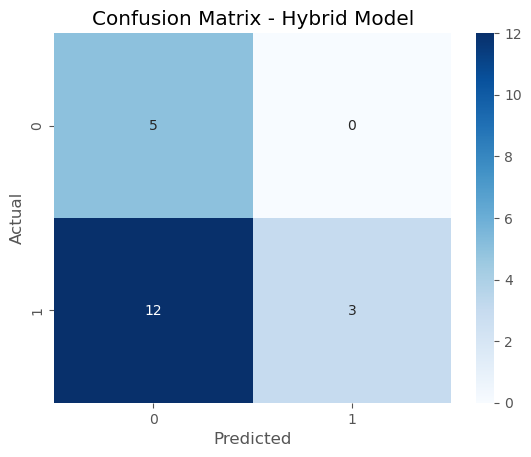

<Figure size 640x480 with 0 Axes>

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Model")
plt.show()
plt.savefig("../plots/confusion_matrix.png", bbox_inches='tight')

## Evaluation & Next month Predictions

In [73]:
payroll_data['joining_date'] = pd.to_datetime(
    payroll_data['joining_date'],
    errors='coerce'
)

In [74]:
payroll_data['year_month'] = payroll_data['joining_date'].dt.to_period('M')

In [75]:
monthly_payroll = payroll_data.groupby('year_month')['net_salary'].sum().reset_index()
monthly_payroll['year_month'] = monthly_payroll['year_month'].astype(str)
monthly_payroll

,year_month,net_salary
0,2023-01,45000.0
1,2023-02,30750.0
2,2023-03,34000.0
3,2023-04,50750.0
4,2023-05,27500.0
5,2023-06,28700.0
6,2023-07,73000.0
7,2023-08,51500.0
8,2023-09,60500.0
9,2023-10,58250.0


In [76]:
monthly_payroll['month_index'] = range(len(monthly_payroll))

In [77]:
monthly_payroll.head()

,year_month,net_salary,month_index
0,2023-01,45000.0,0
1,2023-02,30750.0,1
2,2023-03,34000.0,2
3,2023-04,50750.0,3
4,2023-05,27500.0,4


In [78]:
train_size = int(len(monthly_payroll) * 0.8)

train = monthly_payroll[:train_size]
test = monthly_payroll[train_size:]

In [79]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X_train = train[['month_index']]
y_train = train['net_salary']

model.fit(X_train, y_train)

LinearRegression()

In [80]:
X_test = test[['month_index']]
y_test = test['net_salary']

y_pred = model.predict(X_test)

In [81]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 22959.6047246162
MAPE: 62.285418306064834


In [82]:
next_month_index = pd.DataFrame(
    {'month_index': [len(monthly_payroll)]}
)
next_month_prediction = model.predict(next_month_index)
print("Predicted Next Month Payroll Expense:", next_month_prediction[0])

Predicted Next Month Payroll Expense: 62260.66176470589


In [83]:
import joblib

joblib.dump(model, "payroll_forecast_model.pkl")

['payroll_forecast_model.pkl']

In [84]:
model_features = ['salary_dev_pct', 'net_diff_pct', 'overtime_hours', 'total_deductions']
joblib.dump(model_features, "model_features.pkl")

['model_features.pkl']

In [85]:
payroll_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag', 'true_anomaly',
       'total_deductions', 'deduction_anomaly_score', 'deduction_anomaly_flag',
       'salary_anomaly_score', 'salary_anomaly_flag', 'overtime_anomaly_sco

In [86]:
anomaly_features = [

# salary behaviour
'salary_diff',
'salary_dev_pct',
'robust_z_salary_diff',
'robust_z_salary_dev_pct',
'robust_z_gross_salary',
'robust_z_expected_net',

# deduction behaviour
'total_deductions',
'robust_z_total_deductions',
'robust_z_tax_deduction',
'robust_z_pf_deduction',

# overtime behaviour
'overtime_hours',
'overtime_pay_per_hour',
'robust_z_overtime_pay_per_hour',

# hybrid scores
'salary_if_score_norm',
'deduction_if_score_norm',
'overtime_if_score_norm',

'salary_hybrid_score',
'deduction_hybrid_score',
'overtime_hybrid_score'
]

In [87]:
X = payroll_data[anomaly_features]

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

payroll_data['model_anomaly_flag'] = anomaly_model.fit_predict(X)

# convert -1 / 1 to 1 / 0
payroll_data['model_anomaly_flag'] = payroll_data['model_anomaly_flag'].apply(lambda x: 1 if x == -1 else 0)

In [88]:
payroll_data['final_anomaly_flag'] = (
    (payroll_data['rule_based_anomaly'] == 1) |
    (payroll_data['model_anomaly_flag'] == 1)
).astype(int)

In [89]:
payroll_data['final_anomaly_flag'].value_counts()

final_anomaly_flag
1    15
0     5
Name: count, dtype: int64

In [90]:
import joblib

joblib.dump(anomaly_model, "payroll_anomaly_model.pkl")

['payroll_anomaly_model.pkl']

In [91]:
joblib.dump(anomaly_features, "payroll_anomaly_features.pkl")

['payroll_anomaly_features.pkl']

**Conclusion**

I performed three methods to detect outliers and abnormal behaviour:
1. Isolation forest
2. Robust Zscore method
3. Hybrid method - Isolation + robust Zscore

What I got was that I got better results when I used Isolation forest and robust zscore method together according to biased data that I have, rather than using them individually.

I also drawn the confusion matrix, classification report to evaluate the model performance based on the rule based anomaly and anomalies got using isolation forest + zscore method.\
Further I predict next month payroll using forecasting model.

In [94]:
payroll_data.to_csv("../data/refined_data.csv", index=False)